In [3]:
import pandas as pd

df = pd.read_csv("W1 Physical Activity.csv")

Best Parameters for kcals: {'regressor__max_depth': 10, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 20}
MSE for kcals: 3091237.72
R² Score for kcals: 0.88


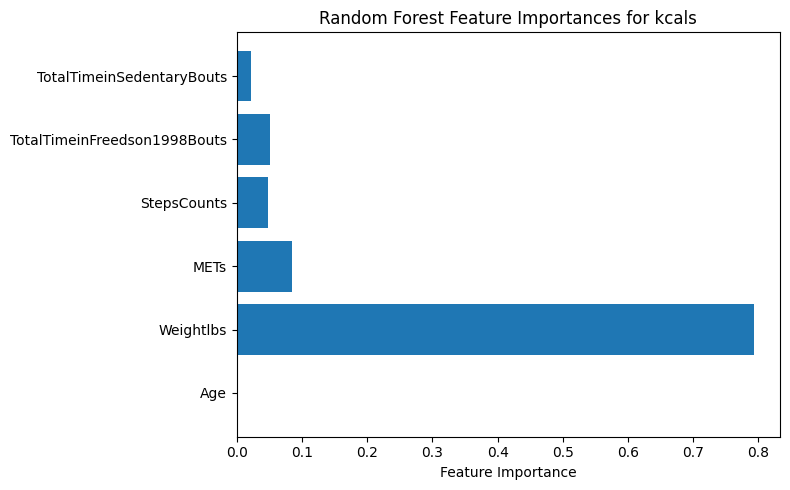

Best Parameters for Averagekcalsperday: {'regressor__max_depth': 10, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 20}
MSE for Averagekcalsperday: 30504.15
R² Score for Averagekcalsperday: 0.92


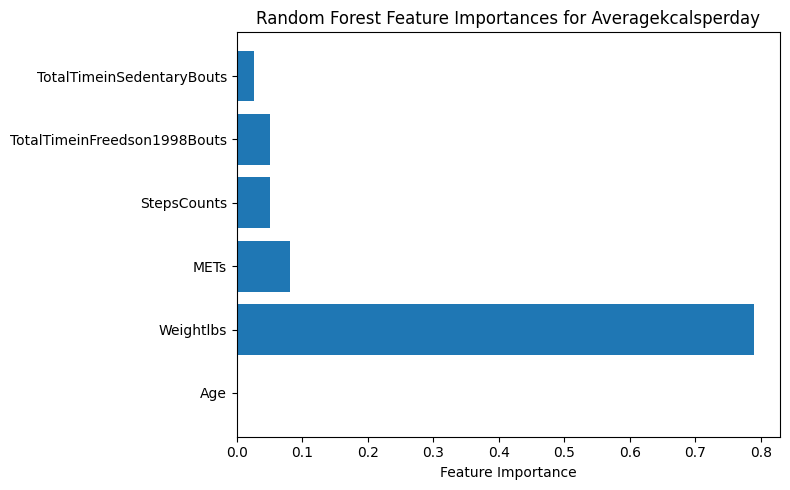

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Selecting features and target variables
features = ['Age', 'Weightlbs', 'METs', 'StepsCounts', 'TotalTimeinFreedson1998Bouts','TotalTimeinSedentaryBouts']
target_vars = ['kcals', 'Averagekcalsperday']

# Drop rows with missing target values just in case
df_model = df[features + target_vars].dropna(subset=target_vars)

# Splitting features and targets
X = df_model[features]

for target_var in target_vars:
    y = df_model[target_var]

    # Creating a pipeline with imputation, scaling, and regression
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('regressor', RandomForestRegressor(random_state=42))
    ])

    # Define hyperparameter grid for RandomForest
    param_grid = {
        'regressor__n_estimators': [20, 50,100, 200],
        'regressor__max_depth': [None, 10, 20],
        'regressor__min_samples_split': [2, 5],
        'regressor__min_samples_leaf': [1, 2]
    }

    # Use 5-fold cross-validation
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    # GridSearchCV for hyperparameter tuning with cross-validation
    grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='r2', n_jobs=-1)

    # Fit the model
    grid_search.fit(X, y)

    # Get best model
    best_model = grid_search.best_estimator_

    # Train-test split to evaluate final model
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)

    # Evaluate performance
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Best Parameters for {target_var}: {grid_search.best_params_}")
    print(f"MSE for {target_var}: {mse:.2f}")
    print(f"R² Score for {target_var}: {r2:.2f}")

    # Feature importances
    rf_model = best_model.named_steps['regressor']
    importances = rf_model.feature_importances_

    # Plotting
    plt.figure(figsize=(8, 5))
    plt.barh(features, importances)
    plt.xlabel("Feature Importance")
    plt.title(f"Random Forest Feature Importances for {target_var}")
    plt.tight_layout()
    plt.show()


Target: kcals
Best Parameters: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 6, 'regressor__n_estimators': 150, 'regressor__subsample': 0.5}
MSE: 1797276.67
R²: 0.93


C:\Users\sarafi\AppData\Local\Temp\ipykernel_34520\3833732697.py:69: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  log_df = pd.concat([


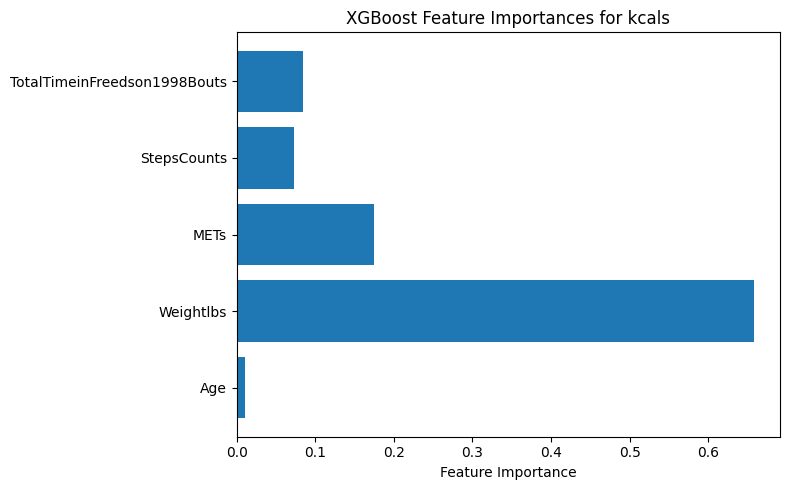

Target: Averagekcalsperday
Best Parameters: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 3, 'regressor__n_estimators': 250, 'regressor__subsample': 0.5}
MSE: 12492.20
R²: 0.97


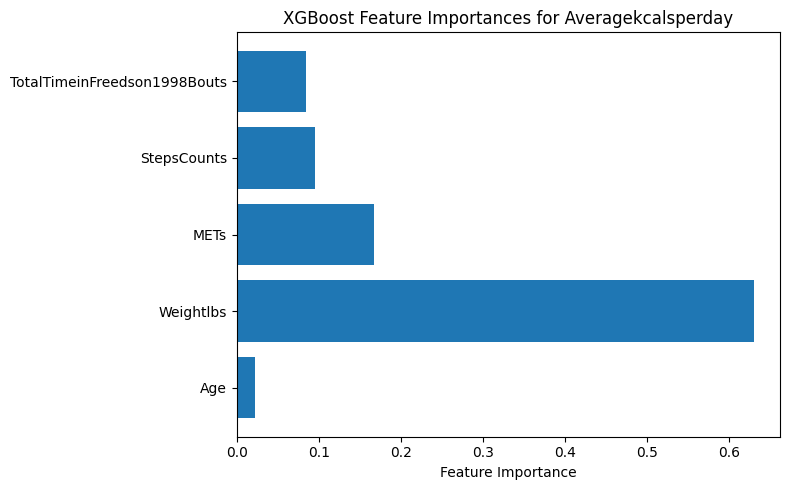

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import joblib  # for saving models
import os

# Create a directory for models and logs
os.makedirs("models", exist_ok=True)
os.makedirs("logs", exist_ok=True)

# Selecting features and target variables
features = ['Age', 'Weightlbs', 'METs', 'StepsCounts', 'TotalTimeinFreedson1998Bouts']
target_vars = ['kcals', 'Averagekcalsperday']

# Drop rows with missing target values just in case
df_model = df[features + target_vars].dropna(subset=target_vars)

# Splitting features and targets
X = df_model[features]

# Create a DataFrame to store log results
log_df = pd.DataFrame(columns=['Target', 'MSE', 'R2', 'BestParams'])

for target_var in target_vars:
    y = df_model[target_var]

    # Pipeline
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('regressor', XGBRegressor(objective='reg:squarederror', random_state=42, verbosity=0))
    ])

    # Hyperparameter grid
    param_grid = {
        'regressor__n_estimators': [100, 150, 200, 250],
        'regressor__max_depth': [3, 6, 10],
        'regressor__learning_rate': [0.01, 0.1, 0.2],
        'regressor__subsample': [0.5, 0.8, 1.0]
    }

    # 5-fold CV
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='r2', n_jobs=-1)
    grid_search.fit(X, y)

    best_model = grid_search.best_estimator_

    # Final train-test split for evaluation
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    best_params = grid_search.best_params_

    print(f"Target: {target_var}")
    print(f"Best Parameters: {best_params}")
    print(f"MSE: {mse:.2f}")
    print(f"R²: {r2:.2f}")

    # Append to log DataFrame
    log_df = pd.concat([
        log_df,
        pd.DataFrame({
            'Target': [target_var],
            'MSE': [mse],
            'R2': [r2],
            'BestParams': [str(best_params)]
        })
    ])

    # Save model
    model_filename = f"models/xgb_model_{target_var}.pkl"
    joblib.dump(best_model, model_filename)

    # Feature importances
    xgb_model = best_model.named_steps['regressor']
    importances = xgb_model.feature_importances_

    plt.figure(figsize=(8, 5))
    plt.barh(features, importances)
    plt.xlabel("Feature Importance")
    plt.title(f"XGBoost Feature Importances for {target_var}")
    plt.tight_layout()
    plt.savefig(f"logs/feature_importance_{target_var}.png")
    plt.show()

# Save log DataFrame to CSV
log_df.to_csv("logs/model_metrics.csv", index=False)
